In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [27]:
data = pd.read_csv(r"C:\Users\AlokVerma\Desktop\ML DATA\TSLA.csv")

data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Select features
data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

print(data.head())

        Open       High        Low      Close      Volume
0  48.599998  48.796001  47.222000  48.174000  29399000.0
1  48.299999  49.189999  47.826000  48.938000  30813000.0
2  48.658001  48.930000  47.886002  48.625999  28157000.0
3  46.372002  46.896000  44.855999  46.605999  75422500.0
4  46.321999  46.956001  45.613998  46.285999  39975000.0


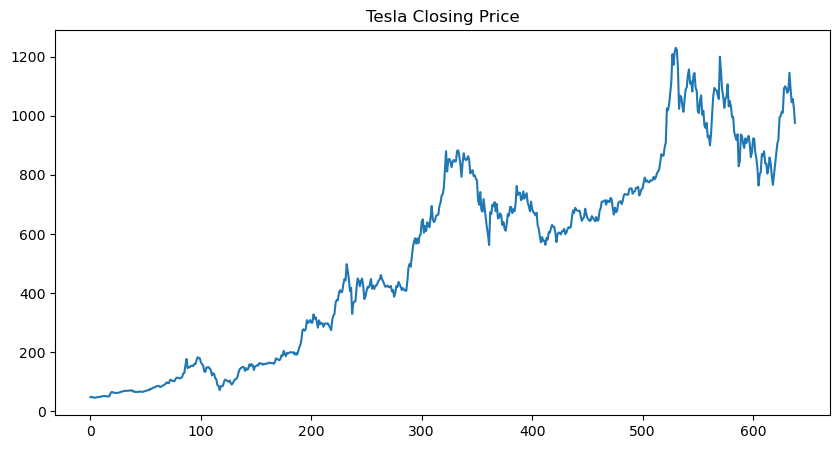

In [28]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Tesla Closing Price")
plt.show()

In [29]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [31]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step][3])  # Close price
    return np.array(X), np.array(y)

X, y = create_dataset(data_scaled, 60)

print(X.shape) 

(579, 60, 5)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False   
)

In [33]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(60,5)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

C:\Users\AlokVerma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 60, 64)              │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - loss: 0.0665 - val_loss: 0.0567
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - loss: 0.0089 - val_loss: 0.0071
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - loss: 0.0039 - val_loss: 0.0109
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - loss: 0.0028 - val_loss: 0.0119
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - loss: 0.0030 - val_loss: 0.0084
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - loss: 0.0031 - val_loss: 0.0111
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0027 - val_loss: 0.0100
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0025 - val_loss: 0.0108
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0023 - val_loss: 0.0076
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0024 - val_loss: 0.0069


In [35]:
pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step


# Convert Back to Original Values

In [36]:
dummy = np.zeros((len(pred), 5))
dummy[:,3] = pred[:,0]

pred_actual = scaler.inverse_transform(dummy)[:,3]

dummy2 = np.zeros((len(y_test), 5))
dummy2[:,3] = y_test

y_actual = scaler.inverse_transform(dummy2)[:,3]

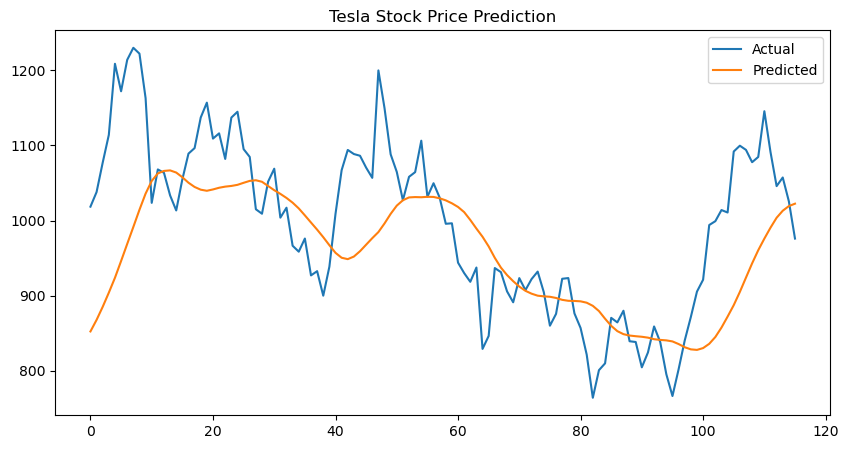

In [39]:
plt.figure(figsize=(10,5))
plt.plot(y_actual, label='Actual')
plt.plot(pred_actual, label='Predicted')
plt.legend()
plt.title("Tesla Stock Price Prediction")
plt.show()

# Evaluate the model

In [40]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_actual, pred_actual)
print("MSE:", mse)

MSE: 9635.056658951098


# Add EarlyStopping

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=3)

model.fit(X_train, y_train, epochs=50, callbacks=[early_stop])

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0026 
Epoch 2/50
 2/15 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0035 

C:\Users\AlokVerma\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0023
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0024 
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0024
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0021
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0025 
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0025
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0020 
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0023
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0020 
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0021
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0020 
Epoch 13/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0020
Epoch 14/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0019 
Epoch 15/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0020
Epoch 16/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0018 
Epo

In [42]:
from tensorflow.keras.layers import Bidirectional

model = Sequential()

model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(60,5)))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(64)))
model.add(Dense(1))

C:\Users\AlokVerma\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
